# Week 8 - Linear Disciminant Analysis and Constrained Optimization

* FDA (2 classes)
    * Compute the class means (in PCA space)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection vector $\mathbf{w}$
    * Compute and plot the 1D projection of the data
    * Compute the class separation of the projected values
* LDA (3 classes)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection matrix $\mathbf{W}$
    * Compute and plot the 2D projection of the data
    * Compute the 2D LDA projection of the original 64D data 
* Constrained Optimization
    * Reformulate the problem as a maximization problem
    * Write out the Lagrangian function
    * Compute the gradients with respects to $x_1, x_2$, Lagrange multiplier $\lambda$ and the KKT multiplier $\mu$
    * Compute the optimum

In [1]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns; sns.set(); sns.set_palette('bright')

## Data
As usual, we'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [2]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [10]:
# Handy plotting functions

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    
def plot_scatter3d(data, targets, view_point=(25, 45), alpha=0.5, legend=True):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data[:,0], data[:,1], data[:,2], c=targets, cmap="rainbow", alpha=alpha)
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    ax.view_init(*view_point) # <- change viewpoint here
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()

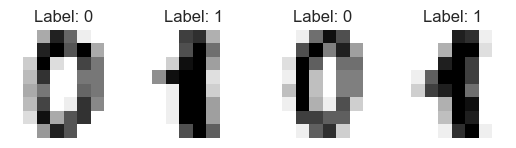

In [4]:
plot_examples()

In [11]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with
t = digits.target

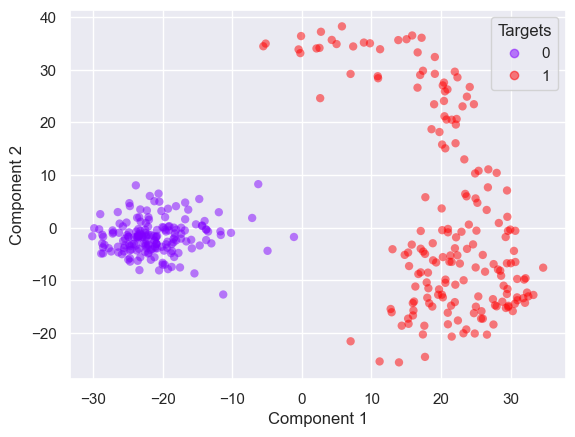

In [12]:
# Let's plot all the data in 2D
plot_scatter(X, t)

## 1) Fisher Discriminant Analysis (FDA)


### 1.1) Compute the class means (in PCA space)

In [13]:
m1 = np.mean(X[t==0], axis = 0)
m2 = np.mean(X[t==1], axis = 0)

m1, m2



(array([-21.14447038,  -1.75335626]), array([20.67975675,  1.71482096]))

### 1.2) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$

In [16]:
Sw = np.zeros((2,2))

for sample in X[t == 0]:
    scatter_t0 = (sample - m1)[:, np.newaxis] @ (sample - m1)[np.newaxis, :]
    Sw += scatter_t0

for sample in X[t == 1]:
    scatter_t1 = (sample - m2)[:, np.newaxis] @ (sample - m2)[np.newaxis, :]
    Sw += scatter_t1

print(Sw)
Sb = (m2 - m1)[:, np.newaxis] @ (m2 - m1)[np.newaxis, :]
print(Sb)

[[ 15041.33444706 -13053.23317691]
 [-13053.23317691  64127.63085988]]
[[1749.26597493  145.05383207]
 [ 145.05383207   12.02825328]]


### 1.3) Compute the projection vector $\mathbf{w}$
Hint: You can use `np.linalg.pinv` and `np.linalg.eig` for computing the pseudo-inverse and eigenvectors, respectively.
Also, remember to ensure that $||w||_2 = 1$

In [21]:
def compute_projection_vector(Sw, S_B):
    # Compute the pseudo-inverse of S_W
    S_W_inv = np.linalg.pinv(Sw)
    
    # Solve the generalized eigenvalue problem
    eigenvalues, eigenvectors = np.linalg.eig(np.dot(S_W_inv, S_B))
    print(eigenvalues)

    print(eigenvectors)
    # Sort eigenvalues and corresponding eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, sorted_indices]

    print(sorted_indices)
    print(eigenvectors)
    # Pick the eigenvector corresponding to the largest eigenvalue
    W = eigenvectors[:, 0]
    
    # Normalize W
    W = W / np.linalg.norm(W)
    print("this is norm", W)

    
    return W


In [22]:
w_1 = np.linalg.pinv(Sw) @ (m2-m1)
W = w_1 /np.linalg.norm(w_1)
W
X_proj = [W.T @ x for x in X]


### 1.4) Compute and plot the 1D projection of the data
Hint: You can use `seaborn.displot` for a nice visualisation

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


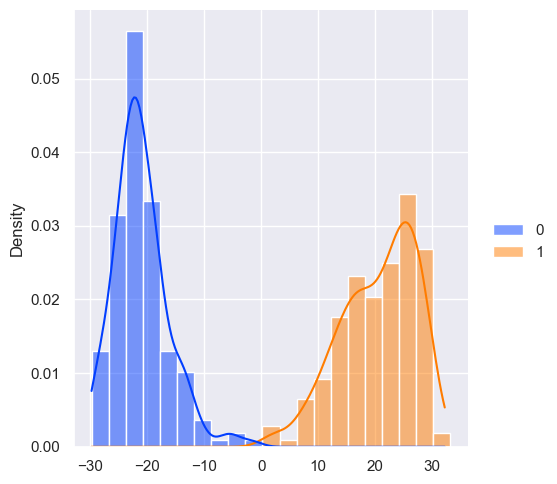

In [23]:
# Plot the 1D projection
sns.displot(x=np.squeeze(X_proj), hue=t, kde=True, stat='density',
kind='hist', binwidth=3)


### 1.5) Compute the class separation of the projected values

In [24]:
W.T @ (m2-m1)

41.596313499803784

## 2) Linear Discriminant Analysis (LDA)

Shape of X: (537, 3)


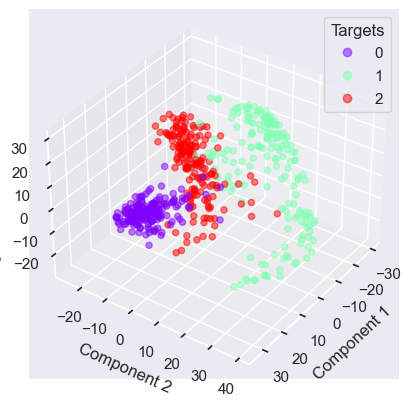

In [25]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=3)
X = pca.fit_transform(digits.data)
t = digits.target
print("Shape of X:", X.shape)


plot_scatter3d(X, t, view_point=(35,35))

### 2.1) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$

In [26]:
Sw = np.zeros((n_class,n_class))

m1 = np.mean(X[t == 0], axis=0)
m2 = np.mean(X[t == 1], axis=0)
m3 = np.mean(X[t == 2], axis=0)

m = [np.mean(X[t == k], axis=0) for k in range(n_class)]
for k in range(n_class):
    for sample in X[t == k]:
        #print()
        Sw += (sample - m[k])[:, np.newaxis] @ (sample - m[k])[np.newaxis, :]

Sb = np.zeros((n_class,n_class))

for k in range(n_class):
    Sb += (m[k] - np.mean(X))[:, np.newaxis] @ (m[k] - np.mean(X))[np.newaxis, :]

print(Sw)
print(Sb)

[[ 27768.47732325  19720.58431948 -19025.65774941]
 [ 19720.58431948  51486.18364408 -18774.45496047]
 [-19025.65774941 -18774.45496047  56959.24520591]]
[[ 940.97091045 -105.70818721  108.09286082]
 [-105.70818721  355.60359535  105.02314287]
 [ 108.09286082  105.02314287   52.35533257]]


### 2.2) Compute the projection matrix $\mathbf{W}$

In [27]:
# Compute the pseudo-inverse of S_W
S_W_inv = np.linalg.pinv(Sw)

# Solve the generalized eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eig(np.dot(S_W_inv, Sb))

# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, sorted_indices]

# Pick the eigenvectors corresponding to the largest eigenvalues
W = eigenvectors[:, :2]  # assuming we are interested in a 2D subspace

# Normalize W
W = W / np.linalg.norm(W, axis=0)

print("W:", W)


W: [[ 0.91774901 -0.12699267]
 [-0.33159216 -0.8266237 ]
 [ 0.21859416 -0.54823911]]


### 2.3) Compute and plot the 2D projection of the data

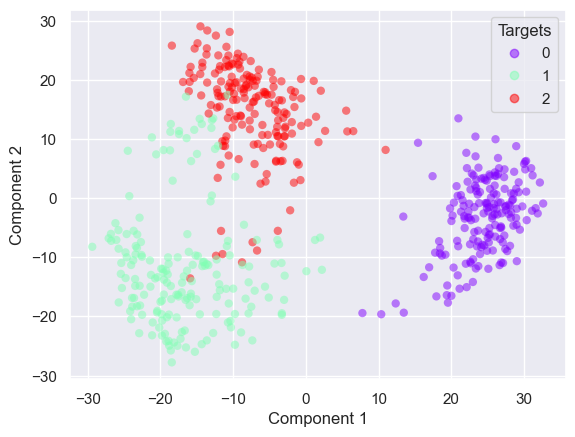

In [ ]:
X_proj = X @ W  

# Plot the 2D projection
plot_scatter(X_proj, t)

### 2.4) Compute and plot the 2D LDA projection of the original 64D data 

In [30]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
X = digits.data
t = digits.target

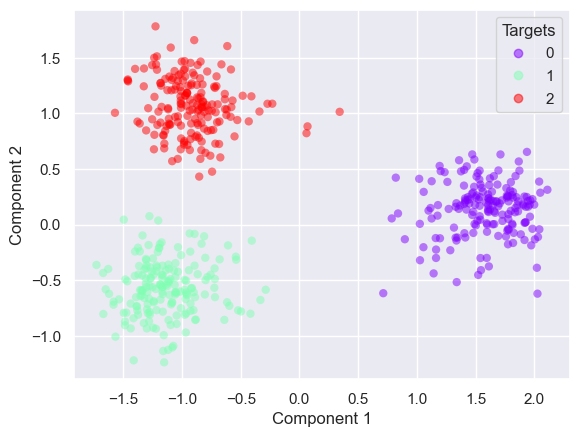

In [38]:
class_means = np.array([np.mean(X[t == i,:], axis = 0) for i in range(3)])
total_mean = np.mean(X, axis = 0)
Ns = np.unique(t, return_counts = True)[1]
 
SW = sum((X[t == i,:] - class_means[i]).T @ (X[t == i,:] - class_means[i]) for i in range(3))
SB = sum(Ns[i] * (class_means[[i]] - total_mean).T @ (class_means[[i]] - total_mean) for i in range(3))
 
 
eigvals, eigenvectors = np.linalg.eig(np.linalg.pinv(SW) @ SB)
idx = eigvals.argsort()[::-1]
 
W = eigenvectors[:,idx[:2]]
 
plot_scatter((W.T @ X.T).T, t)

Comment on the general utility of the projection as compared to PCA

Well in LDA we are maximazing class separability and PCA is trying to maximize variance and does not consider class labels.
LDA is supervised reuqring class labels and PCA is unsupervised not requiring class labels.
LDA Assumes that the classes have identical covariance matrices



# 3) Constrained Optimization
 
Consider the problem

minimize $f_{min}(x_1, x_2)$

subject to $ x_1 + x_2 \leq 4 
\quad \text{ and } \quad x_1 + 4x_2 = 5 
$
where $f_{min}(x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2$

## 3.1) Reformulate the problem as a canonical maximization problem
_Use the form described in the end of "Pattern Recognition and Machine Learning" Appendix E._

_NB: There is an error in appendix E: $h(x) \leq 0$, not $h(x) \geq 0$._

Minimize f(x) subject to g(x) = 0 and h(x) >= -4
$$
g(x) = x_1 + x_2 -5
$$
$$
h(x) = -(x_1 + 4x_2 -4)
$$


## 3.2) Write out the Lagrangian function
_Use Equation (E.12) in "Pattern Recognition and Machine Learning" Appendix E., and write out all variables_

\begin{equation}
L(x_1, x_2, \lambda, \mu) = (x_1 - 3)^2 + (x_2 - 2)^2 - \lambda(x_1 + 4x_2-5) - \mu(x_1 + x_2 - 4)
\end{equation}


## 3.3) Compute the gradients with respects to $x_1, x_2$, lagrange multiplier $\lambda$ and the KKT multiplier $\mu$

$$
2x_1 -6 - \lambda - \mu = 0
$$
$$
2x_2 - 4\lambda - \mu  = 0
$$
$$
-x_1 -4x_2 +5 = 0
$$
$$
-x_1 - x_2 + 4 = 0
$$

## 3.4) Compute the optimum
_Hint: Set it up as a system of linear equations and solve it using Gaussian Elimination (e.g. using `scipy.linalg.solve`)_

In [56]:
import scipy.linalg

A = np.array([[2, 0, 1, 1],
              [0, 2, 1, 4],
              [1, 4, 0, 0],
              [1, 1, 0, 0]])

b = np.array([[6],
              [4],
              [5],
              [4]])

x = scipy.linalg.solve(A, b)

print("Solution x:")
print(x)


Solution x:
[[ 3.66666667]
 [ 0.33333333]
 [-2.88888889]
 [ 1.55555556]]
